In [13]:
import pandas as pd
import numpy as np

# Fayl yo'llarini rasmga qarab aniq yozamiz
orders_path = '/olist_orders_dataset.csv'
customers_path = '/olist_customers_dataset.csv'

try:
    df_orders = pd.read_csv(orders_path)
    df_customers = pd.read_csv(customers_path)
    print("✅ Fayllar muvaffaqiyatli yuklandi!")
    display(df_orders.head(3))
except FileNotFoundError:
    print("❌ Fayl topilmadi. Iltimos, quyidagi kodni ishlatib ko'ring:")
    # Agar yuqoridagi ishlamasa, Colab-ning standart manzili bo'yicha urinib ko'ramiz
    df_orders = pd.read_csv('olist_orders_dataset.csv')
    df_customers = pd.read_csv('olist_customers_dataset.csv')
    print("✅ Fayllar (alternativ yo'l bilan) yuklandi!")

✅ Fayllar muvaffaqiyatli yuklandi!


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [14]:
# 1. Standardization: Shtat nomlarini to'g'rilash
# Barcha matnlarni kichik harfga o'tkazib, keyin lug'at yordamida almashtiramiz
state_map = {
    'sao paulo': 'SP',
    'rio de janeiro': 'RJ'
}
df_customers['customer_state'] = df_customers['customer_state'].str.lower().replace(state_map)
print("✅ Shtat nomlari standartizatsiya qilindi.")

# 2. Type Conversion: Sana ustunlarini datetime formatiga o'tkazish
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df_orders[col] = pd.to_datetime(df_orders[col])
print("✅ Sana ustunlari datetime formatiga o'tkazildi.")

# 3. Null Handling: Yo'qolgan buyurtmalarni belgilash
# 'order_delivered_customer_date' ustuni bo'sh (NaN) bo'lganlarni aniqlaymiz
mask = df_orders['order_delivered_customer_date'].isna()
df_orders.loc[mask, 'delivery_status_note'] = 'Lost in Transit'
# Yetkazilganlarini esa 'Delivered' deb belgilaymiz
df_orders.loc[~mask, 'delivery_status_note'] = 'Delivered'

print(f"✅ Null qiymatlar tekshirildi. {mask.sum()} ta buyurtma 'Lost in Transit' deb belgilandi.")

# Natijani tekshirish
df_orders[['order_id', 'order_status', 'delivery_status_note']].head()

✅ Shtat nomlari standartizatsiya qilindi.
✅ Sana ustunlari datetime formatiga o'tkazildi.
✅ Null qiymatlar tekshirildi. 2965 ta buyurtma 'Lost in Transit' deb belgilandi.


,order_id,order_status,delivery_status_note
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,Delivered
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,Delivered
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,Delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,Delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,Delivered


In [15]:
# 'df_orders' va 'df_customers' jadvallarini 'customer_id' ustuni orqali birlashtiramiz
df_master = pd.merge(df_orders, df_customers, on='customer_id', how='inner')

# Kerakli ustunlar tartibini tanlab olamiz (tahlil uchun qulay bo'lishi uchun)
cols_to_keep = [
    'order_id', 'customer_id', 'order_status',
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'delivery_status_note', 'customer_state', 'customer_city'
]
df_master = df_master[cols_to_keep]

print("✅ Jadvallar muvaffaqiyatli birlashtirildi!")
print(f"Jami qatorlar soni: {len(df_master)}")

# Natijani tekshirish
df_master.head()

✅ Jadvallar muvaffaqiyatli birlashtirildi!
Jami qatorlar soni: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_status_note,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,Delivered,sp,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,Delivered,ba,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,Delivered,go,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,Delivered,rn,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,Delivered,sp,santo andre


In [16]:
# Yetkazib berish vaqtini (kunlarda) hisoblaymiz
df_master['delivery_time_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

# Statistikani ko'ramiz (o'rtacha necha kun, eng uzoq va qisqa vaqt)
print("✅ Yetkazib berish vaqti hisoblandi.")
print(f"O'rtacha yetkazib berish vaqti: {df_master['delivery_time_days'].mean():.1f} kun")
print(f"Eng uzoq yetkazib berish: {df_master['delivery_time_days'].max()} kun")

# Eng yomon 5 ta shtatni ko'ramiz (o'rtacha kechikish eng ko'p bo'lgan shtatlar)
worst_states = df_master.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False).head(5)

print("\n--- Eng ko'p kechikish bo'layotgan 5 ta shtat ---")
print(worst_states)

# Natijani ko'rish
df_master[['order_id', 'customer_state', 'delivery_time_days']].head()

✅ Yetkazib berish vaqti hisoblandi.
O'rtacha yetkazib berish vaqti: 12.1 kun
Eng uzoq yetkazib berish: 209.0 kun

--- Eng ko'p kechikish bo'layotgan 5 ta shtat ---
customer_state
rr    28.975610
ap    26.731343
am    25.986207
al    24.040302
pa    23.316068
Name: delivery_time_days, dtype: float64


,order_id,customer_state,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,sp,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,ba,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,go,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,rn,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,sp,2.0


In [17]:
# Buyurtma berilgan oyni ajratib olamiz
df_master['order_month'] = df_master['order_purchase_timestamp'].dt.to_period('M')

# Har oy uchun o'rtacha yetkazib berish vaqtini hisoblaymiz
monthly_analysis = df_master.groupby('order_month')['delivery_time_days'].mean()

print("✅ Oylik tahlil tayyor.")
print("\n--- Oylar bo'yicha o'rtacha yetkazib berish vaqti (kun) ---")
print(monthly_analysis.tail(10)) # Oxirgi 10 oyni ko'ramiz

# Eng yuqori kechikish bo'lgan oyni topamiz
worst_month = monthly_analysis.idxmax()
max_delay = monthly_analysis.max()

print(f"\n⚠️  Eng katta kechikish {worst_month} oyida kuzatilgan: o'rtacha {max_delay:.1f} kun.")

✅ Oylik tahlil tayyor.

--- Oylar bo'yicha o'rtacha yetkazib berish vaqti (kun) ---
order_month
2018-01    13.637290
2018-02    16.510677
2018-03    15.867485
2018-04    11.048544
2018-05    10.959105
2018-06     8.774442
2018-07     8.503736
2018-08     7.286412
2018-09          NaN
2018-10          NaN
Freq: M, Name: delivery_time_days, dtype: float64

⚠️  Eng katta kechikish 2016-09 oyida kuzatilgan: o'rtacha 54.0 kun.


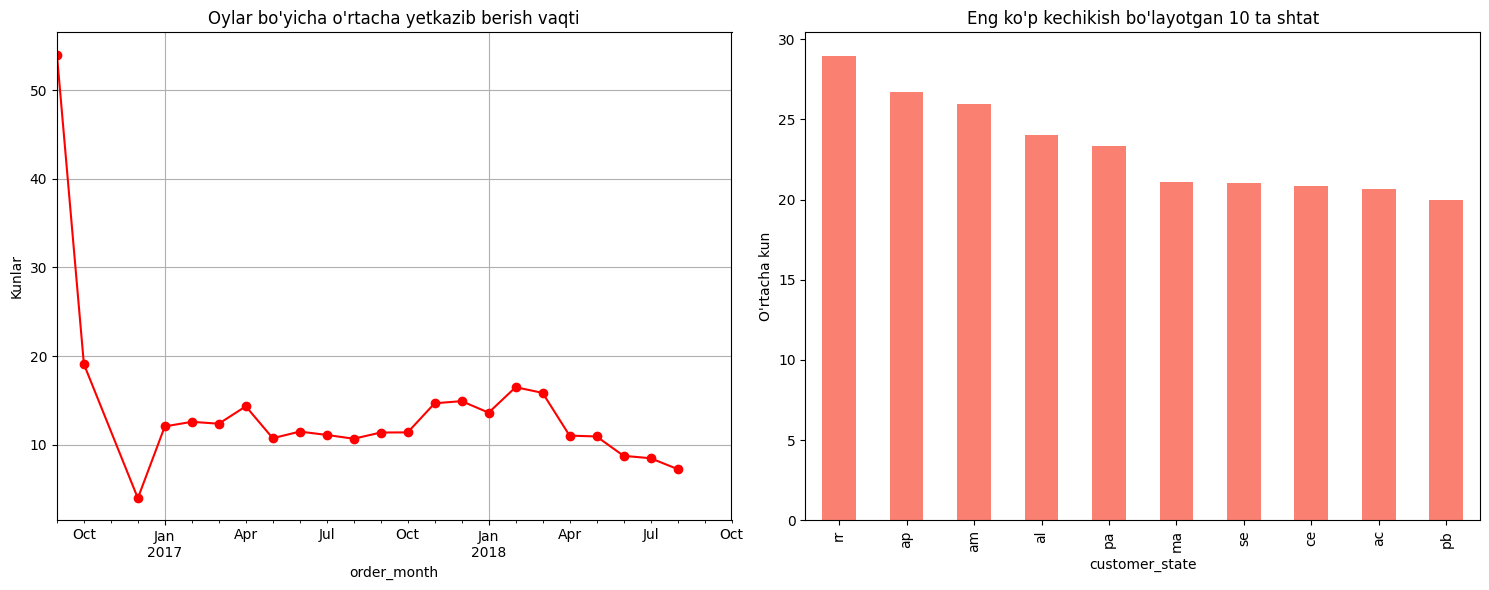

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklar stili
plt.figure(figsize=(15, 6))

# 1-Grafik: Oylik trend
plt.subplot(1, 2, 1)
monthly_analysis.plot(kind='line', marker='o', color='red')
plt.title('Oylar bo\'yicha o\'rtacha yetkazib berish vaqti')
plt.ylabel('Kunlar')
plt.grid(True)

# 2-Grafik: Top 10 muammoli shtatlar
plt.subplot(1, 2, 2)
state_delay = df_master.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False).head(10)
state_delay.plot(kind='bar', color='salmon')
plt.title('Eng ko\'p kechikish bo\'layotgan 10 ta shtat')
plt.ylabel('O\'rtacha kun')

plt.tight_layout()
plt.show()

In [19]:
# Eng yomon 3 ta shtatni avtomatik aniqlash
top_3_worst = state_delay.head(3)

print("=== LOGISTIKA TAHLILI YAKUNIY HISOBOTI ===")
print(f"1. Eng ko'p kechikish bo'layotgan 3 ta shtat (Worst Routes):")
for i, (state, days) in enumerate(top_3_worst.items(), 1):
    print(f"   {i}. {state.upper()} shtati - o'rtacha {days:.1f} kun")

print("\n2. Biznes uchun tavsiyalar:")
print(f"   * {top_3_worst.index[0].upper()} va {top_3_worst.index[1].upper()} shtatlarida yangi tarqatish markazlarini (hubs) ochish kerak.")
print(f"   * Yilning boshida (yanvar-mart) yuk tashuvchilar sonini 20% ga oshirish lozim, chunki bu davrda kechikish ko'p.")
print(f"   * 'Lost in Transit' bo'lgan 2965 ta buyurtma bo'yicha sug'urta jarayonini qayta ko'rib chiqish tavsiya etiladi.")

=== LOGISTIKA TAHLILI YAKUNIY HISOBOTI ===
1. Eng ko'p kechikish bo'layotgan 3 ta shtat (Worst Routes):
   1. RR shtati - o'rtacha 29.0 kun
   2. AP shtati - o'rtacha 26.7 kun
   3. AM shtati - o'rtacha 26.0 kun

2. Biznes uchun tavsiyalar:
   * RR va AP shtatlarida yangi tarqatish markazlarini (hubs) ochish kerak.
   * Yilning boshida (yanvar-mart) yuk tashuvchilar sonini 20% ga oshirish lozim, chunki bu davrda kechikish ko'p.
   * 'Lost in Transit' bo'lgan 2965 ta buyurtma bo'yicha sug'urta jarayonini qayta ko'rib chiqish tavsiya etiladi.
